In [1]:
import pandas as pd
import psycopg2
import yfinance as yf
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text
import warnings

# 모든 경고 무시
warnings.filterwarnings("ignore")
load_dotenv()

True

In [2]:
import os
from sqlalchemy import create_engine, text

host = os.environ["SUPABASE_HOST"]
port = os.environ.get("SUPABASE_PORT", 5432)
db   = os.environ["SUPABASE_DB"]
user = os.environ["SUPABASE_USER"]
pw   = os.environ["SUPABASE_PASSWORD"]

url = f"postgresql+psycopg2://{user}:{pw}@{host}:{port}/{db}?sslmode=require"
engine = create_engine(url, connect_args={"sslmode":"require"}, pool_pre_ping=True)

with engine.begin() as conn:
    df_test = pd.read_sql("SELECT * FROM stock_data", engine)

In [3]:
ticker_alias = pd.read_excel("..\\stock_list.xlsx")
df = pd.merge(df_test, ticker_alias, on = 'ticker', how='inner')
df = pd.pivot_table(df, index = 'date', columns = 'alias', values = "close").reset_index()
df = df[df.nasdaq.notna()]

In [5]:
for col in df.columns:
    if col == "date":
        pass
    else :
        df[f"{col}_monthly"] = df[col].pct_change(21)

In [12]:
df['금/은'] = df['금']/df['은']

In [18]:
df = pd.melt(df, id_vars = 'date').dropna()

In [20]:
with engine.begin() as conn:
    df.to_sql("stock_addp", con=conn, if_exists="replace", index=False)
    print('DB saved')

DB saved


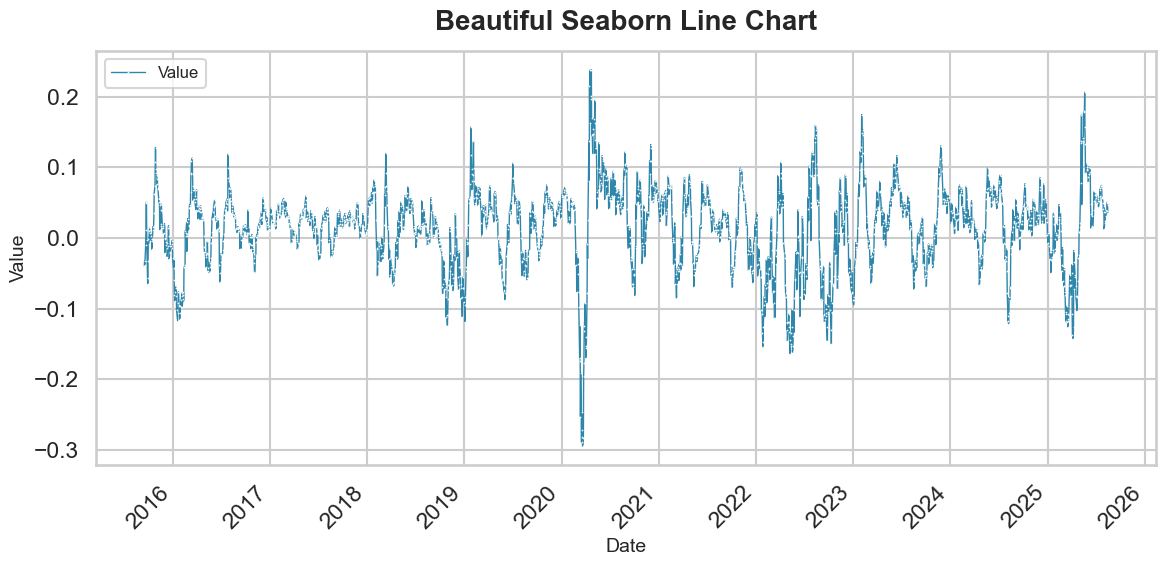

In [10]:
# Seaborn 스타일 설정
sns.set_theme(style="whitegrid")  # whitegrid / darkgrid / white / dark
sns.set_context("talk")  # talk / paper / notebook / poster

# 라인 차트
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x="date",
    y="nasdaq_monthly",
    linewidth=1,
    color="#2E86AB",  # 파란 계열
    marker="o",       # 데이터 포인트 표시
    markersize=0.5
)

# 타이틀 & 라벨
plt.title("Beautiful Seaborn Line Chart", fontsize=20, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Value", fontsize=14)

# x축 날짜 포맷
plt.xticks(rotation=45, ha='right')

# 범례 (필요시)
plt.legend(["Value"], loc="upper left", fontsize=12)

# 여백 조정
plt.tight_layout()
plt.show()


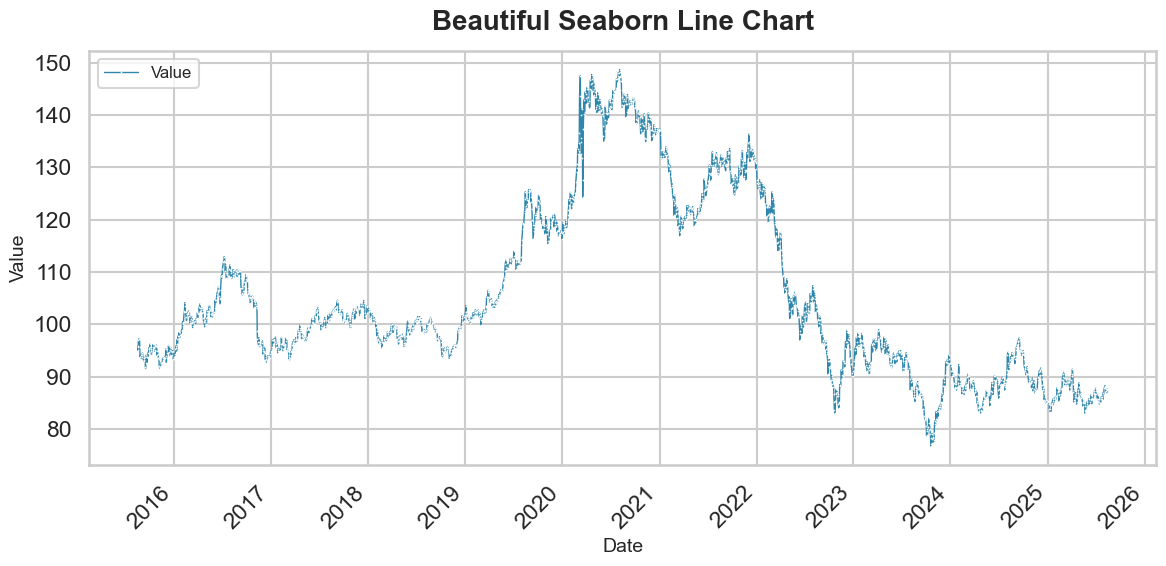

In [83]:
# Seaborn 스타일 설정
sns.set_theme(style="whitegrid")  # whitegrid / darkgrid / white / dark
sns.set_context("talk")  # talk / paper / notebook / poster

# 라인 차트
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x="date",
    y="미국장기채ETF",
    linewidth=1,
    color="#2E86AB",  # 파란 계열
    marker="o",       # 데이터 포인트 표시
    markersize=0.5
)

# 타이틀 & 라벨
plt.title("Beautiful Seaborn Line Chart", fontsize=20, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Value", fontsize=14)

# x축 날짜 포맷
plt.xticks(rotation=45, ha='right')

# 범례 (필요시)
plt.legend(["Value"], loc="upper left", fontsize=12)

# 여백 조정
plt.tight_layout()
plt.show()


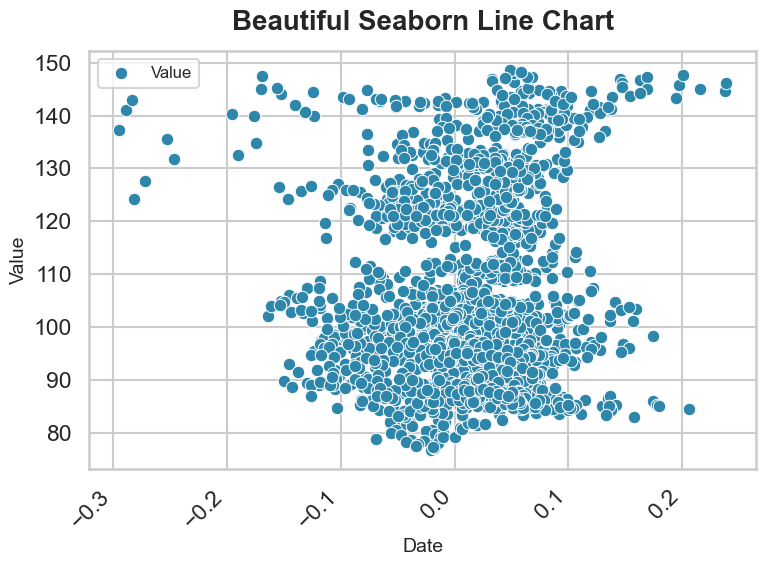

In [84]:
# Seaborn 스타일 설정
sns.set_theme(style="whitegrid")  # whitegrid / darkgrid / white / dark
sns.set_context("talk")  # talk / paper / notebook / poster

# 라인 차트
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="nasdaq_monthly",
    y="미국장기채ETF",
    color="#2E86AB",  # 파란 계열
    marker="o",       # 데이터 포인트 표시
)

# 타이틀 & 라벨
plt.title("Beautiful Seaborn Line Chart", fontsize=20, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Value", fontsize=14)

# x축 날짜 포맷
plt.xticks(rotation=45, ha='right')

# 범례 (필요시)
plt.legend(["Value"], loc="upper left", fontsize=12)

# 여백 조정
plt.tight_layout()
plt.show()
